# Importação de Pacotes

In [69]:
#leitura da base de dados
import pandas as pd
from pathlib import Path

#modelo preditivo escolhido
from sklearn.ensemble import GradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

In [70]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(
        ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
    )

    print(f"""
      Acurária: {round(acuracia,3)};
      Revocação: {round(recall,3)};
      F1: {round(F1,3)};
      Roc_Auc: {round(roc_auc,3)}""")

## Leitura DataFrame

In [71]:
direcao = Path("../..") / "data"
caminho = direcao / "dados_confrontados_completo.csv"

df = pd.read_csv(caminho)

### Escolha do Modelo

In [72]:
modelo= GradientBoostingClassifier()

### Escolha dos HiperParâmetros

In [73]:
parametros = {
    "modelo__n_estimators": [100], 
    "modelo__max_depth": [2], 
    "modelo__max_leaf_nodes": [10],
    "modelo__learning_rate": [0.2]
    }

In [74]:
df.columns

Index(['d', 'data_peticao', 'tipo_documento', 'materialidade_valor',
       'materialidade_categoria', 'legitimidade_representante',
       'tipo_legitimidade', 'clareza_objetividade', 'fundamentacao_minima',
       'indicios_irregularidade', 'competencia_tcu', 'recursos_federais',
       'demanda_privada', 'interesse_publico',
       'type_restricao_admissibilidade', 'type_evidencia_indicio_minimo',
       'type_aceitabilidade_evidencia_jornalistica', 'type_nivel_indicio',
       'pedido_medida_cautelar', 'contrato_vigente', 'contrato_iminente',
       'criticidade_objeto', 'certame_suspenso', 'risco_erario',
       'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe',
       'type_contrato_objeto_previsto', 'type_regularizacao_requisito',
       'type_defesa_ente_administrativo', 'type_impacto_irregularidade',
       'perigo_demora_reverso', 'fumus_boni_iuris', 'categoria_irregularidade',
       'dano_potencial_alto', 'dano_potencial_medio',
       'nexo_causal_identif

# Aplicação de Pipelines

In [76]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.2], 'modelo__max_depth': [2], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.725;
      Revocação: 0.404;
      F1: 0.46;
      Roc_Auc: 0.63


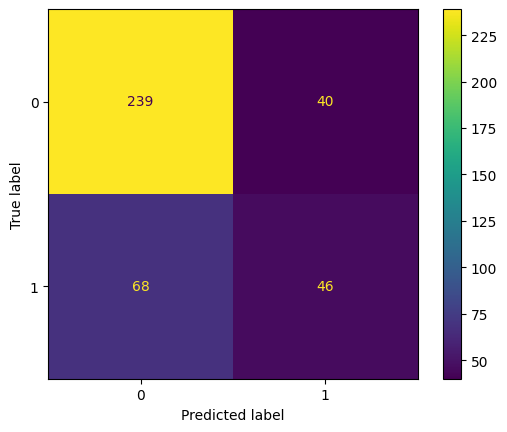

In [77]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Teste com mais Parâmetros**

In [90]:
parametros = {
    "modelo__n_estimators": [100, 200, 1000], 
    "modelo__max_depth": [1, 2, 3], 
    "modelo__max_leaf_nodes": [10, 20, 30],
    "modelo__learning_rate": [0.01, 0.2, 1.0]
    }

In [91]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.01, 0.2, ...], 'modelo__max_depth': [1, 2, ...], 'modelo__max_leaf_nodes': [10, 20, ...], 'modelo__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.73;
      Revocação: 0.333;
      F1: 0.418;
      Roc_Auc: 0.613


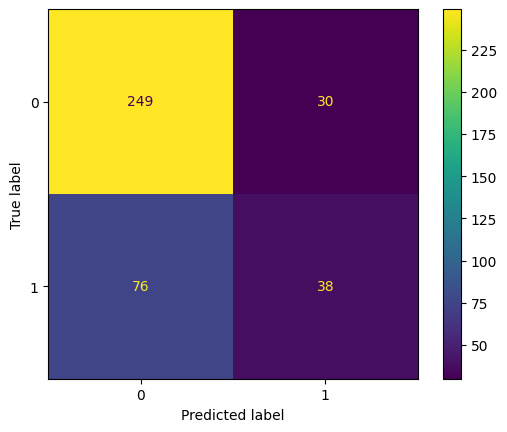

In [92]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Extração de Amostras para Análise Qualitativa de Falsos Positivos e Negativos**

In [93]:
import numpy as np

y_pred = searchCV_pipeline.predict(X_test)

resultados = X_test.copy()
resultados["y"] = y_test.values
resultados["y_pred"] = y_pred

falso_positivo = resultados[(resultados["y"] == 0) & (resultados["y_pred"] == 1)]
falso_negativo = resultados[(resultados["y"] == 1) & (resultados["y_pred"] == 0)]

amostra_fp = falso_positivo.sample(n=min(10, len(falso_positivo)), random_state=22)
amostra_fn= falso_negativo.sample(n=min(10, len(falso_negativo)), random_state=22)

### Análise Falso Positivo

In [94]:
len(falso_positivo)

30

In [95]:
amostra_fp

,materialidade_valor,materialidade_categoria,legitimidade_representante,tipo_legitimidade,clareza_objetividade,fundamentacao_minima,indicios_irregularidade,competencia_tcu,recursos_federais,demanda_privada,...,evidencias_documentos_contabeis,evidencias_midiaticas,evidencias_testemunhais,qualidade_evidencias_forte,qualidade_evidencias_moderada,autenticidade_documentos_certificada,autenticidade_documentos_presumida,resposta_ente_convincente,y,y_pred
1131,1.000000e+10,alta,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0,1
1109,0.000000e+00,baixa,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
980,0.000000e+00,baixa,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1
533,0.000000e+00,baixa,sim,mpu,sim,sim,sim,sim,nao,nao,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
27,0.000000e+00,baixa,sim,mpu,sim,sim,sim,sim,nao,nao,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
1230,0.000000e+00,baixa,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0,1
645,0.000000e+00,baixa,sim,mpu,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
1300,0.000000e+00,baixa,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
239,0.000000e+00,media,sim,orgao_controle,sim,sim,sim,sim,nao,nao,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
109,1.000000e+09,alta,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1


### Análise Falso Negativo

In [96]:
len(falso_negativo)

76

In [97]:
amostra_fn

,materialidade_valor,materialidade_categoria,legitimidade_representante,tipo_legitimidade,clareza_objetividade,fundamentacao_minima,indicios_irregularidade,competencia_tcu,recursos_federais,demanda_privada,...,evidencias_documentos_contabeis,evidencias_midiaticas,evidencias_testemunhais,qualidade_evidencias_forte,qualidade_evidencias_moderada,autenticidade_documentos_certificada,autenticidade_documentos_presumida,resposta_ente_convincente,y,y_pred
22,6.973520e+05,media,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,1.0,0.0,0.000000,1.000000,0.000000,1.000000,0.00,1,0
361,1.615152e+05,media,sim,cidadao,sim,sim,sim,nao,nao,nao,...,0.0,0.0,0.0,0.250000,0.750000,0.000000,1.000000,0.25,1,0
136,1.266501e+05,baixa,sim,cidadao,sim,sim,sim,nao,sim,nao,...,0.5,0.5,0.0,0.000000,1.000000,0.000000,1.000000,0.00,1,0
748,2.000000e+06,media,sim,outro,sim,sim,sim,sim,nao,nao,...,0.0,0.0,0.0,0.333333,0.666667,1.000000,0.000000,0.00,1,0
797,3.155000e+08,alta,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.000000,1.000000,0.000000,1.000000,0.00,1,0
441,1.733490e+08,alta,sim,cidadao,sim,sim,sim,sim,sim,nao,...,0.0,0.0,0.0,0.333333,0.666667,0.666667,0.333333,1.00,1,0
1000,1.400000e+10,alta,sim,parlamentar,sim,sim,sim,sim,nao,nao,...,0.0,0.0,0.0,1.000000,0.000000,1.000000,0.000000,0.00,1,0
936,4.080000e+09,alta,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,1.0,0.0,0.000000,1.000000,0.000000,1.000000,0.00,1,0
1174,1.854071e+07,alta,sim,cidadao,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.000000,0.000000,1.000000,0.000000,0.00,1,0
861,1.021172e+06,media,sim,outro,sim,sim,sim,sim,sim,nao,...,0.0,0.0,0.0,1.000000,0.000000,1.000000,0.000000,0.00,1,0


# Feature Importance aplicada à Base de Dados (Shapley)

In [99]:
import shap

best_pipeline = searchCV_pipeline.best_estimator_

best_model = best_pipeline.named_steps["modelo"]
preprocessor = best_pipeline.named_steps["preprocessor"]

X_importance = preprocessor.transform(X_test)

cat_encoder = (preprocessor.named_transformers_["cat"].named_steps["onehot"])

feature_names = list(cat_encoder.get_feature_names_out(lista_X))


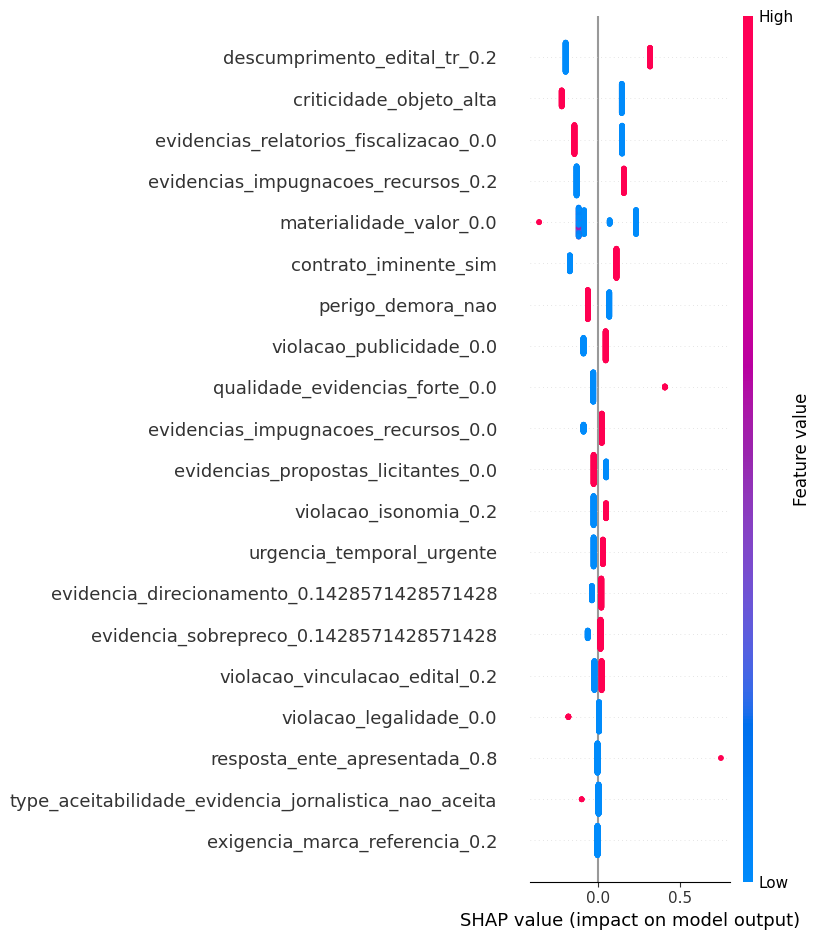

In [100]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_importance)

shap.summary_plot(shap_values, X_importance, feature_names)

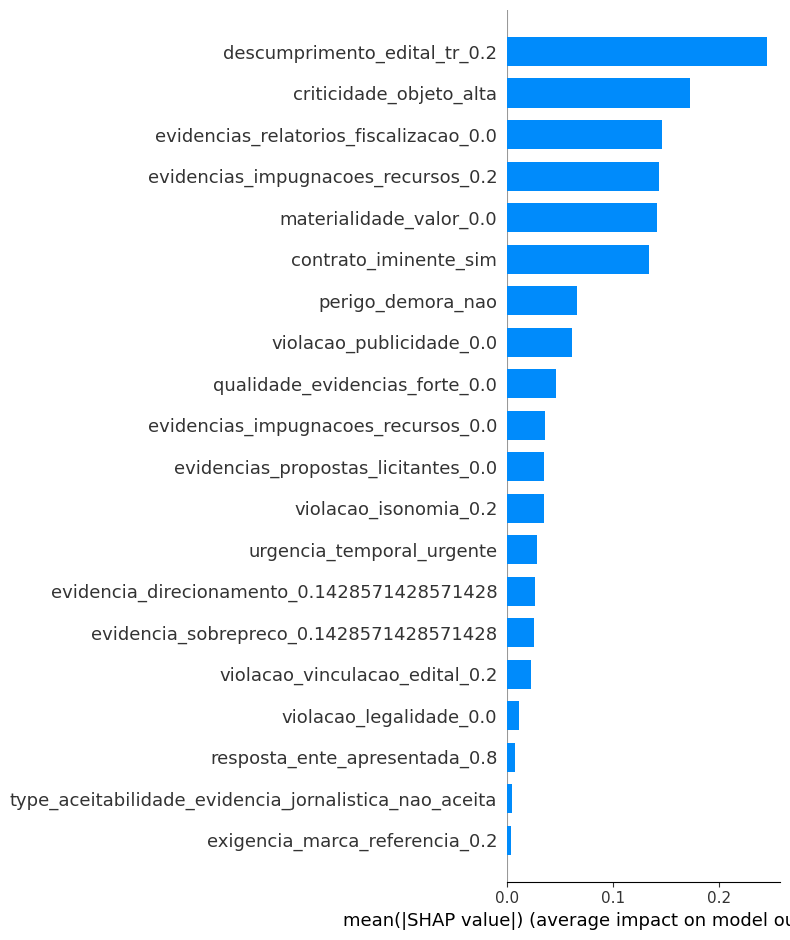

In [101]:
shap.summary_plot(shap_values, X_importance, feature_names, plot_type='bar')